c:\Programming\Projects\formula_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\Techno\.cache\kagglehub\datasets\rohanrao\formula-1-world-championship-1950-2020\versions\24


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [37]:
status = pd.read_csv(path + "/status.csv")
status.head()
seasons = pd.read_csv(path + "/seasons.csv")
seasons.head()
sprint = pd.read_csv(path + "/sprint_results.csv")
sprint.head()


qualifying = pd.read_csv(path + "/qualifying.csv")
qualifying.head()
drivers = pd.read_csv(path + "/drivers.csv")
drivers.head(15)


,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen
5,6,nakajima,\N,NAK,Kazuki,Nakajima,1985-01-11,Japanese,http://en.wikipedia.org/wiki/Kazuki_Nakajima
6,7,bourdais,\N,BOU,Sébastien,Bourdais,1979-02-28,French,http://en.wikipedia.org/wiki/S%C3%A9bastien_Bo...
7,8,raikkonen,7,RAI,Kimi,Räikkönen,1979-10-17,Finnish,http://en.wikipedia.org/wiki/Kimi_R%C3%A4ikk%C...
8,9,kubica,88,KUB,Robert,Kubica,1984-12-07,Polish,http://en.wikipedia.org/wiki/Robert_Kubica
9,10,glock,\N,GLO,Timo,Glock,1982-03-18,German,http://en.wikipedia.org/wiki/Timo_Glock


In [38]:
results = pd.read_csv(path + "/results.csv")
results.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


In [39]:
races = pd.read_csv(path + "/races.csv")
races.loc[17]

raceId                                                        18
year                                                        2008
round                                                          1
circuitId                                                      1
name                                       Australian Grand Prix
date                                                  2008-03-16
time                                                    04:30:00
url            http://en.wikipedia.org/wiki/2008_Australian_G...
fp1_date                                                      \N
fp1_time                                                      \N
fp2_date                                                      \N
fp2_time                                                      \N
fp3_date                                                      \N
fp3_time                                                      \N
quali_date                                                    \N
quali_time               

In [40]:
drivers_standings = pd.read_csv(path + "/driver_standings.csv")
drivers_standings.head()
#Probably the most important table for understanding the championship standings. Can be helpful for finding the total points for each driver.

,driverStandingsId,raceId,driverId,points,position,positionText,wins
0,1,18,1,10.0,1,1,1
1,2,18,2,8.0,2,2,0
2,3,18,3,6.0,3,3,0
3,4,18,4,5.0,4,4,0
4,5,18,5,4.0,5,5,0


In [71]:
top30_drivers_by_points = drivers_standings.groupby("driverId").sum()["points"].sort_values(ascending=False)[:30].reset_index()

top30_drivers_by_points = pd.merge(top30_drivers_by_points, drivers, how="left", left_on="driverId", right_on="driverId")[["driverId", "points", "forename", "surname"]]
top30_drivers_by_points

,driverId,points,forename,surname
0,1,51153.5,Lewis,Hamilton
1,830,32849.5,Max,Verstappen
2,20,32026.0,Sebastian,Vettel
3,4,24579.0,Fernando,Alonso
4,822,19541.0,Valtteri,Bottas
5,8,19069.0,Kimi,Räikkönen
6,815,18893.0,Sergio,Pérez
7,3,16910.0,Nico,Rosberg
8,844,16024.0,Charles,Leclerc
9,30,14514.0,Michael,Schumacher


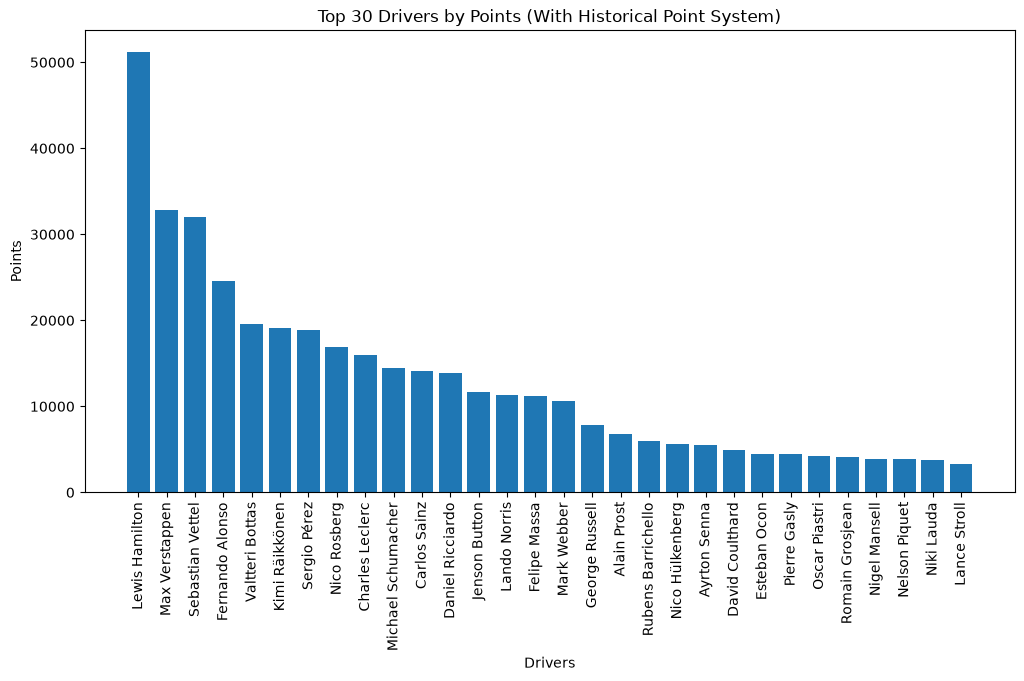

In [ ]:
labels = (top30_drivers_by_points["forename"] + " " + top30_drivers_by_points["surname"])

plt.figure(figsize=(12, 6))

plt.bar(labels, top30_drivers_by_points["points"])
plt.xlabel("Drivers")
plt.ylabel("Points")
plt.title("Top 30 Drivers by Points (With Historical Point System)")
plt.xticks(rotation=90)

plt.show()

In [73]:
point_distribution = {
    1: 25,
    2: 18,
    3: 15,
    4: 12,
    5: 10,
    6: 8,
    7: 6,
    8: 4,
    9: 2,
    10: 1
}

drivers_standings_recalculated = drivers_standings.copy()

drivers_standings_recalculated["modern_points"] = drivers_standings_recalculated["position"].map(point_distribution).fillna(0)

top30_drivers_by_points_recalculated = drivers_standings_recalculated.groupby("driverId").sum()["modern_points"].sort_values(ascending=False)[:30].reset_index()

top30_drivers_by_points_recalculated = pd.merge(top30_drivers_by_points_recalculated, drivers, how="left", left_on="driverId", right_on="driverId")[["driverId", "modern_points", "forename", "surname"]]

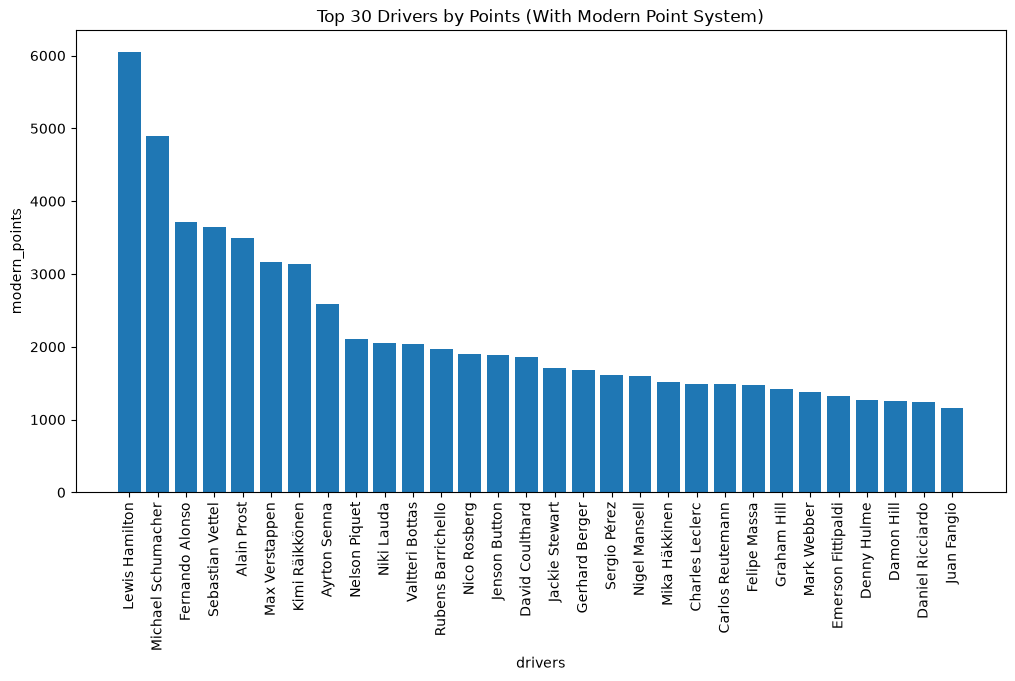

In [83]:
labels_recalculated = (top30_drivers_by_points_recalculated["forename"] + " " + top30_drivers_by_points_recalculated["surname"]) 

plt.figure(figsize=(12, 6))

plt.bar(labels_recalculated, top30_drivers_by_points_recalculated["modern_points"])
plt.xticks(rotation=90)
plt.xlabel("drivers")
plt.ylabel("modern_points")
plt.title("Top 30 Drivers by Points (With Modern Point System)")

plt.show()